### Block 0: Drawing circuit from the paper

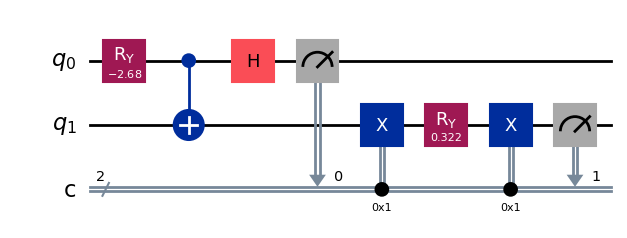

In [75]:
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
import numpy as np

h = 1
k = 0.5

def qet_circuit(theta, phi):
    """Generates the QET circuit using Qiskit.

    Args:
        theta: Rotation angle for initial state preparation.
        phi: Rotation angle for Bob's conditional operation.

    Returns:
        Qiskit QuantumCircuit object representing the QET circuit.
    """

    # Initialize qubits and classical bit
    q = QuantumRegister(2, 'q')
    c = ClassicalRegister(2, 'c')
    circuit = QuantumCircuit(q, c)

    # Prepare ground state
    circuit.ry(2 * theta, q[0])
    circuit.cx(q[0], q[1])

    # Alice's measurement
    circuit.h(q[0])
    circuit.measure(q[0], c[0])

    # Bob's conditional operation using a conditional rotation
    circuit.x(q[1]).c_if(c, 1)  # Apply X gate to q[1] if classical bit c is 1
    circuit.ry(2 * phi, q[1])   # Apply RY gate to q[1] 
    circuit.x(q[1]).c_if(c, 1)  # Undo the X gate if it was applied

    # Measurement of Bob's qubit
    circuit.measure(q[1], c[1])  # Add a new classical bit for Bob's measurement

    return circuit

# Example usage
theta = -1 * np.arccos(1 / np.sqrt(2) * np.sqrt(1 - h / np.sqrt(h**2 + k**2)))  # Calculate theta based on h, k
phi = 0.5 * np.arcsin(h * k / np.sqrt((h**2 + 2 * k**2)**2 + h**2 * k**2))  # Calculate phi based on h, k

qet_circuit = qet_circuit(theta, phi)
qet_circuit.draw('mpl')  # Draw the circuit using matplotlib

### Block 1: Import necessary libraries

In [ ]:
from qiskit import QuantumCircuit, transpile
from qiskit.visualization import plot_histogram, circuit_drawer
from qiskit_aer import Aer
from qiskit.quantum_info import SparsePauliOp
from qiskit.primitives import BackendEstimatorV2
from qiskit.circuit import ClassicalRegister
import numpy as np

### Block 2: Define the QET circuit function

In [78]:
def qet_circuit(h, k):
    """
    Constructs the quantum circuit for the QET experiment.

    Args:
      h: Parameter h for the Hamiltonian.
      k: Parameter k for the Hamiltonian.

    Returns:
      qc: The constructed QuantumCircuit object.
    """

    qc = QuantumCircuit(2, 4)

    # Prepare the ground state
    theta = -np.arccos(
        (1 / np.sqrt(2)) * np.sqrt(1 - h / np.sqrt(h**2 + k**2))
    )
    qc.ry(2 * theta, 0)
    qc.cx(0, 1)

    # Alice's measurement
    qc.measure(0, 0)  # Measure qbit 0 and store the result in classical bit 0

    # Bob's conditional operation
    phi = np.arcsin(
        (h * k) / np.sqrt((h**2 + 2 * k**2)**2 + h**2 * k**2)
    ) / 2

    # Bob's conditional operation
    qc.cry(2 * phi, 0, 1).c_if(0, 0)  # Apply U(+1) if classical bit 0 is 0
    qc.cry(-2 * phi, 0, 1).c_if(0, 1)  # Apply U(-1) if classical bit 0 is 1

    qc.measure(1, 1)  # Measure qubit 1 into classical bit 1

    qc.h(0)
    qc.h(1)
    qc.measure(0, 2)  # Measure qubit 0 into classical bit 2
    qc.measure(1, 3)  # Measure qubit 1 into classical bit 3

    return qc

### Block 3: Simulation

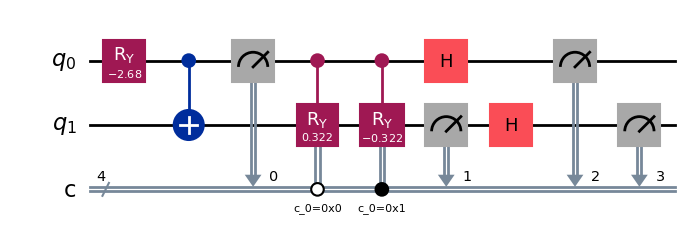

In [79]:
# Choose parameters
h = 1
k = 0.5

# Construct the circuit
qc = qet_circuit(h, k)

# Use the Qiskit simulator
simulator = Aer.get_backend('qasm_simulator')
qc_compiled = transpile(qc, simulator)

job_sim = simulator.run(qc_compiled, shots=1024)
result_sim = job_sim.result()
counts_sim = result_sim.get_counts(qc_compiled)

circuit_drawer(qc, output='mpl')

### Block 3.1: Plot simulation results

Simulation results:
{'00 0': 15, '10 0': 27, '11 1': 644, '01 1': 338}


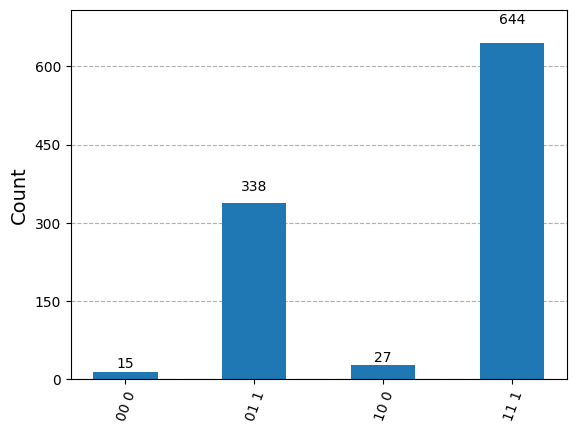

In [23]:
# Print and plot results
print("Simulation results:")
print(counts_sim)
plot_histogram(counts_sim)

### Block 4: Execution on real quantum hardware

#### Block 4.1: Build `h1` circuit

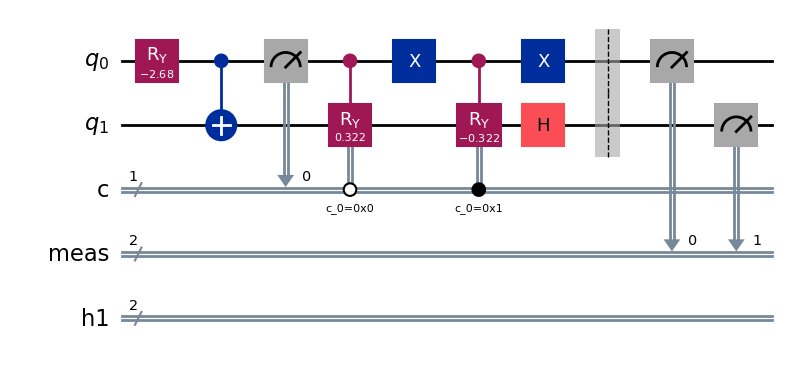

In [ ]:
h1 = SparsePauliOp.from_list([("ZI", h), ("II", h**2 / np.sqrt(h**2 + k**2))])

qc_h1 = qet_circuit(h, k)
cr_h1 = ClassicalRegister(h1.num_qubits, 'h1')
qc_h1.add_register(cr_h1)
# Apply gates for H_1 measurement
for pauli, coeff in h1.to_list():
    if pauli == "Z":
        qc_h1.z(0)  # Apply Z gate to qubit 0
    # Add other cases for different Pauli terms if needed

circuit_drawer(qc_h1, output='mpl')

#### Block 4.2: Build `v` circuit

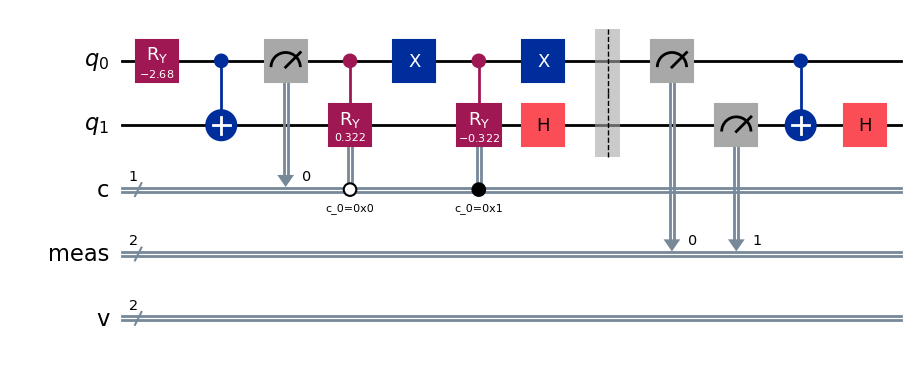

In [31]:
v = SparsePauliOp.from_list([("XX", 2 * k), ("II", 2 * k**2 / np.sqrt(h**2 + k**2))])

qc_v = qet_circuit(h, k)
cr_v = ClassicalRegister(v.num_qubits, 'v')
qc_v.add_register(cr_v)  # Add the ClassicalRegister
# Apply gates for V measurement
for pauli, coeff in v.to_list():
    if pauli == "XX":
        qc_v.cx(0, 1)  # Apply CX gate for XX
        qc_v.h(1)  # Apply Hadamard for measurement in X basis
    # Add other cases for different Pauli terms if needed

circuit_drawer(qc_v, output='mpl')

#### Block 4.3: Execute

In [69]:
# Choose IBM Quantum backend
from qiskit_ibm_runtime import QiskitRuntimeService

service = QiskitRuntimeService()
backend = service.backend('ibm_brisbane')

# Use Estimator to get expectation values
estimator = BackendEstimatorV2(backend=backend)  # Initialize Estimator

In [ ]:
# Execute the circuits and get expectation values
qc_h1_transpiled = transpile(qc_h1, backend)
num_qubits_transpiled = qc_h1_transpiled.num_qubits
h1_expanded = SparsePauliOp.from_list([("Z" + "I" * (num_qubits_transpiled - 1), h),
                                     ("I" * num_qubits_transpiled, h**2 / np.sqrt(h**2 + k**2))])
pub_h1 = (qc_h1_transpiled, [h1_expanded], None)
job_h1 = estimator.run([pub_h1])
result_h1 = job_h1.result()

In [68]:
qc_v_transpiled = transpile(qc_v, backend)
num_qubits_transpiled = qc_v_transpiled.num_qubits
v_expanded = SparsePauliOp.from_list([("XX" + "I" * (num_qubits_transpiled - 2), 2 * k),
                                     ("I" * num_qubits_transpiled, 2 * k**2 / np.sqrt(h**2 + k**2))])
pub_v = (qc_v_transpiled, [v_expanded], None)
job_v = estimator.run([pub_v])
result_v = job_v.result()

/home/amir/Documents/git/quantum/ibm/.venv/lib/python3.12/site-packages/qiskit_ibm_runtime/ibm_backend.py:727: UserWarning: The backend ibm_kyiv is currently paused.
  warnings.warn(f"The backend {self.name} is currently paused.")


RuntimeInvalidStateError: 'Unable to retrieve result for job cwskk2w997wg008xk7bg. Job was cancelled.'

In [ ]:
expectation_value_h1 = result_h1._pub_results[0].data.values()
expectation_value_v = result_v._pub_results[0].data.values()

# Print expectation values
print("Expectation value of H_1:", expectation_value_h1)
print("Expectation value of V:", expectation_value_v)

#######################################################
# job_real = assemble(qc_compiled, shots=1024)

# # Execute on the backend
# result_real = backend.run(job_real).result()
# counts_real = result_real.get_counts(qc_compiled)

# # Print and plot results
# print("Real quantum computer results:")
# print(counts_real)
# plot_histogram(counts_real)

Expectation value of H_1: dict_values([array([1.85682953]), array([0.00424419])])


### Block 5: Analyze the results

In [ ]:
# ... (Refer to the paper for analysis techniques)